In [15]:
from dataclasses import dataclass
import equinox as eqx
import jax
import jax.numpy as jnp
import JAX_data_generator as jdg
import JAX_visualization as viz
import matplotlib.pyplot as plt
import numpy as np
import optax


In [16]:
n_k1 = 500

zref = 40
ustar = 1.773
k1_arr = jnp.logspace(-1, 2, n_k1) / zref

data = jdg.generate_kaimal_data(k1_arr, zref, ustar)

/Users/matthewmeeker/Work/DRDMannTurb/JAX_REWRITE/JAX_visualization.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 1, 0.97])


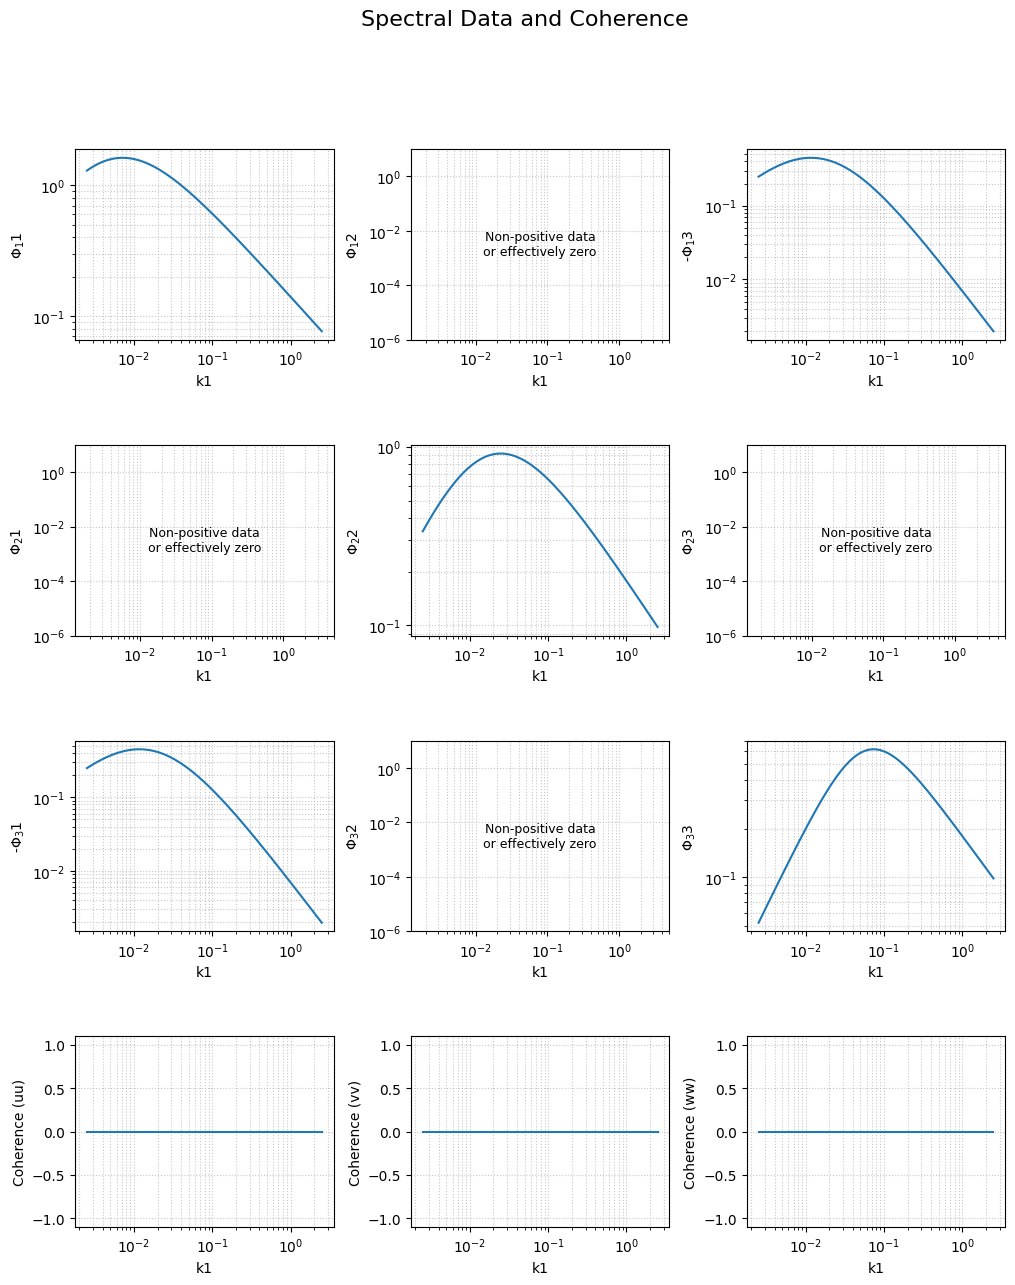

In [17]:
viz.plot_generated_data(data)

In [18]:
class SimpleNN(eqx.Module):

    layers: list

    def __init__(self, nlayers, inlayer = 3, hlayer = 3, outlayer = 3, key=None):
        keys = jax.random.split(key, nlayers+1)

        self.layers = []

        # Input layer
        self.layers.append(eqx.nn.Linear(inlayer, hlayer, key=keys[0]))

        # Hidden layers
        for i in range(1, nlayers):
            self.layers.append(eqx.nn.Linear(hlayer, hlayer, key=keys[i]))

        # Output layer
        self.layers.append(eqx.nn.Linear(hlayer, outlayer, key=keys[-1]))


    def __call__(self, x):
        """Call magic function."""
        y = x
        # for i, layer in enumerate(self.layers[:-1]):
        for layer in self.layers[:-1]:
            y = jax.nn.relu(layer(y))

        y = self.layers[-1](y)

        return y + x
        

In [19]:
class Rational(eqx.Module):  
    nu: jnp.ndarray  
    learn_nu: bool  
      
    def __init__(self, learn_nu=True, key=None):  
        self.learn_nu = learn_nu  
        nu_init = -1.0/3.0  
          
        if self.learn_nu:  
            self.nu = jnp.array(nu_init)  
        else:  
            # Static field is used to mark nu as a constant
            self.nu = eqx.static_field(jnp.array(nu_init))  
      
    def __call__(self, x):  
        a = self.nu - 2/3  
        b = self.nu  
        out = jnp.abs(x)  
        out = out**a / (1 + out**2)**(b/2)  
        return out


In [20]:
class TauNet(eqx.Module):  
    elt_neural_network: SimpleNN  
    rational_module: Rational  
      
    def __init__(self, n_layers=2, hidden_layer_size=3, learn_nu=True, key=None):  
        keys = jax.random.split(key, 2)  
        self.elt_neural_network = SimpleNN(  
            nlayers=n_layers,  
            inlayer=3,  
            hlayer=hidden_layer_size,  
            outlayer=3,  
            key=keys[0]  
        )  
        self.rational_module = Rational(learn_nu=learn_nu, key=keys[1])  
      
    def __call__(self, k):  
        k_abs = jnp.abs(k)
        k_mod = jnp.linalg.norm(self.NN(k_abs), axis=-1)  
        tau = self.rational_module(k_mod)  
        return tau


In [ ]:
# Implement one point spectra


@dataclass
class PhysicalParameters:
    L: float  # Length scale
    Gamma: float  # Characteristic time scale
    sigma: float  # Spectrum amplitude

class OnePointSpectra(eqx.Module):
    # Parameters (will be automatically handled by Equinox)
    LengthScale: float
    TimeScale: float
    Magnitude: float
    
    # Grids (these will be static, not parameters)
    grid_k2: jnp.ndarray
    grid_k3: jnp.ndarray
    meshgrid23: Tuple[jnp.ndarray, jnp.ndarray]
    
    def __init__(
        self,
        physical_params: PhysicalParameters,
        *,
        key: Optional[jax.random.PRNGKey] = None
    ):
        # Validate physical parameters
        assert physical_params.L > 0, "Length scale L must be positive."
        assert physical_params.Gamma > 0, "Characteristic time scale Gamma must be positive."
        assert physical_params.sigma > 0, "Spectrum amplitude sigma must be positive."
        
        # Set parameters directly (no need for log/exp conversion in JAX)
        self.LengthScale = physical_params.L
        self.TimeScale = physical_params.Gamma
        self.Magnitude = physical_params.sigma
        
        # Create k2 grid
        p1, p2, N = -3, 3, 100
        grid_zero = jnp.array([0.], dtype=jnp.float64)
        grid_plus = jnp.logspace(p1, p2, N, dtype=jnp.float64)
        grid_minus = -jnp.flip(grid_plus)
        self.grid_k2 = jnp.concatenate([grid_minus, grid_zero, grid_plus])
        
        # Create k3 grid
        grid_zero = jnp.array([0.], dtype=jnp.float64)
        grid_plus = jnp.logspace(p1, p2, N, dtype=jnp.float64)
        grid_minus = -jnp.flip(grid_plus)
        self.grid_k3 = jnp.concatenate([grid_minus, grid_zero, grid_plus])
        
        # Create meshgrid
        self.meshgrid23 = jnp.meshgrid(self.grid_k2, self.grid_k3, indexing="ij")

    def __call__(self, k1_input: jnp.ndarray) -> jnp.ndarray:
        """Evaluate one point spectra.
        
        Args:
            k1_input: Discrete k1 wavevector domain.
            
        Returns:
            Network output
        """
        # Create 3D wavevector grid
        k = jnp.stack(jnp.meshgrid(k1_input, self.grid_k2, self.grid_k3, indexing="ij"), axis=-1)
        k123 = k[..., 0], k[..., 1], k[..., 2]
        
        # Compute beta (eddy lifetime)
        beta = self.EddyLifetime(k)
        
        # Compute k0
        k0 = k.at[..., 2].set(k[..., 2] + beta * k[..., 0])
        
        # Compute k0L and E0
        k0L = self.LengthScale * jnp.linalg.norm(k0, axis=-1)
        E0 = self.Magnitude * self.LengthScale ** (5.0 / 3.0) * VKEnergySpectrum(k0L)
        
        # Compute power spectra
        Phi = self.PowerSpectra(k, beta, E0)
        
        # Compute final result
        kF = jnp.stack([k1_input * self.quad23(Phi, k) for Phi in Phi])
        return kF

    def EddyLifetime(self, k: jnp.ndarray) -> jnp.ndarray:
        """Evaluate eddy lifetime function."""
        kL = self.LengthScale * jnp.linalg.norm(k, axis=-1)
        # For now, using simple -2/3 power law
        tau = kL ** (-2/3)
        return self.TimeScale * tau

    def PowerSpectra(self, k: jnp.ndarray, beta: jnp.ndarray, E0: jnp.ndarray) -> Tuple[jnp.ndarray, ...]:
        """Compute RDT power spectra."""
        return PowerSpectraRDT(k, beta, E0)

    def quad23(self, f: jnp.ndarray, k: jnp.ndarray) -> jnp.ndarray:
        """Approximate integral using trapezoidal rule."""
        # Integration in k3
        quad = jnp.trapz(f, x=k[..., 2], axis=-1)
        
        # Integration in k2
        quad = jnp.trapz(quad, x=k[..., 0, 1], axis=-1)
        return quad





